In [32]:

# Importing Libraries


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Display all columns
pd.set_option('display.max_columns', None)

# Display decimal values up to 2 places
pd.options.display.float_format = '{:.2f}'.format

print("Libraries Imported Successfully!")


Libraries Imported Successfully!


In [33]:
import pandas as pd

df = pd.read_csv("Professional_HR_Analytics_Dataset_15000.csv")
df.head()

# Display Last 5 Rows


df.tail()

# Display Random 5 Rows


df.sample(5)

# Dataset Shape


print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

# Column Names


df.columns

# Data Types


df.dtypes


# Statistical Summary


df.describe()

df.describe(include='all')


# Missing Values


df.isnull().sum()

missing = df.isnull().sum()

missing[missing > 0]


# Duplicate Records


df.duplicated().sum()

print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")

df.memory_usage(deep=True)

df.nunique()

print("Departments")
print(df["Department"].unique())

print()

print("Job Roles")
print(df["Job_Role"].unique())

print()

print("Gender")
print(df["Gender"].unique())

print()

print("Attrition")
print(df["Attrition"].unique())

Number of Rows : 15000
Number of Columns : 28
Dataset contains 15000 rows and 28 columns.
Departments
['Sales' 'IT' 'Customer Support' 'Marketing' 'HR' 'Finance' 'R&D'
 'Operations']

Job Roles
['Analyst' 'Manager' 'Associate' 'Specialist' 'Engineer' 'Executive']

Gender
['Male' 'Female']

Attrition
['Yes' 'No']


In [34]:
# Create a copy of the original dataset
df_clean = df.copy()

print("Rows :", df_clean.shape[0])
print("Columns :", df_clean.shape[1])

missing_values = df_clean.isnull().sum()

missing_values[missing_values > 0]

missing_percentage = (df_clean.isnull().sum() / len(df_clean)) * 100

missing_percentage[missing_percentage > 0]

df_clean["Monthly_Income"] = df_clean["Monthly_Income"].fillna(df_clean["Monthly_Income"].median())

df_clean["Distance_From_Home"] = df_clean["Distance_From_Home"].fillna(df_clean["Distance_From_Home"].median())

df_clean["Job_Satisfaction"] = df_clean["Job_Satisfaction"].fillna(df_clean["Job_Satisfaction"].median())

df_clean.isnull().sum()

df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates()
df_clean.duplicated().sum()

print(df.shape)
print(df_clean.shape)
df_clean.dtypes
df_clean.columns = df_clean.columns.str.lower()
df_clean.columns
df_clean["department"].unique()
object_columns = df_clean.select_dtypes(include="object").columns

for col in object_columns:
    df_clean[col] = df_clean[col].str.strip()
df_clean.describe()
for col in df_clean.select_dtypes(include="object"):
    print(f"\n{col}")
    print(df_clean[col].unique())
df_clean.to_csv("HR_Analytics_Cleaned.csv", index=False)

Rows : 15000
Columns : 28
(15000, 28)
(15000, 28)

gender
['Male' 'Female']

department
['Sales' 'IT' 'Customer Support' 'Marketing' 'HR' 'Finance' 'R&D'
 'Operations']

job_role
['Analyst' 'Manager' 'Associate' 'Specialist' 'Engineer' 'Executive']

education
['PhD' 'Master' 'Bachelor' 'Diploma']

marital_status
['Married' 'Single' 'Divorced']

business_travel
['Rarely' 'Non-Travel' 'Frequently']

overtime
['Yes' 'No']

remote_work
['No' 'Yes']

attrition
['Yes' 'No']


In [35]:
df_fe = df_clean.copy()
df_fe = pd.read_csv("HR_Analytics_Cleaned.csv")
df_fe["age_group"] = pd.cut(
    df_fe["age"],
    bins=[20,30,40,50,60],
    labels=["21-30","31-40","41-50","51-60"]
)
df_fe["income_category"] = pd.cut(
    df_fe["monthly_income"],
    bins=[0,5000,8000,12000,50000],
    labels=["Low","Medium","High","Very High"]
)
df_fe["experience_level"] = pd.cut(
    df_fe["total_working_years"],
    bins=[0,5,10,20,40],
    labels=["Entry","Mid","Senior","Expert"]
)
df_fe["attrition_flag"] = df_fe["attrition"].map({
    "Yes":1,
    "No":0
})
df_fe["attrition"].value_counts()
df_fe["attrition_flag"].mean()
df_fe["overtime_flag"] = df_fe["overtime"].map({
    "Yes":1,
    "No":0
})
df_fe["satisfaction_category"] = pd.cut(
    df_fe["job_satisfaction"],
    bins=[0,2,3,4],
    labels=["Low","Medium","High"]
)
df_fe["salary_hike_category"] = pd.cut(
    df_fe["percent_salary_hike"],
    bins=[0,12,18,25],
    labels=["Low","Average","High"]
)
df_fe["tenure_group"] = pd.cut(
    df_fe["years_at_company"],
    bins=[0,2,5,10,30],
    labels=["New","Junior","Experienced","Veteran"]
)
df_fe["remote_work_flag"] = df_fe["remote_work"].map({
    "Yes":1,
    "No":0
})
df_fe["high_performer"] = np.where(
    df_fe["performance_rating"] >= 4,
    "Yes",
    "No"
)
df_fe.head()
df_fe.info()
df_fe.to_csv("HR_Analytics_Feature_Engineered.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 38 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   employee_id                 15000 non-null  int64   
 1   age                         15000 non-null  int64   
 2   gender                      15000 non-null  object  
 3   department                  15000 non-null  object  
 4   job_role                    15000 non-null  object  
 5   education                   15000 non-null  object  
 6   marital_status              15000 non-null  object  
 7   business_travel             15000 non-null  object  
 8   distance_from_home          15000 non-null  float64 
 9   monthly_income              15000 non-null  float64 
 10  bonus                       15000 non-null  int64   
 11  overtime                    15000 non-null  object  
 12  job_satisfaction            15000 non-null  float64 
 13  environment_sati

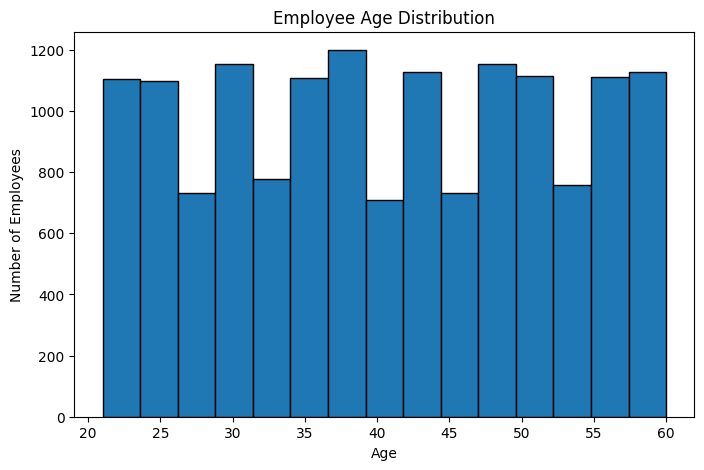

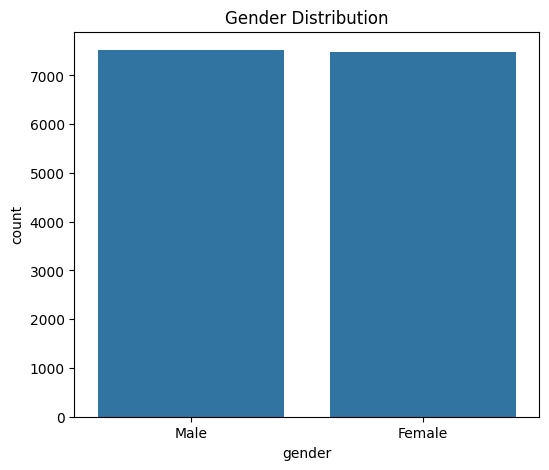

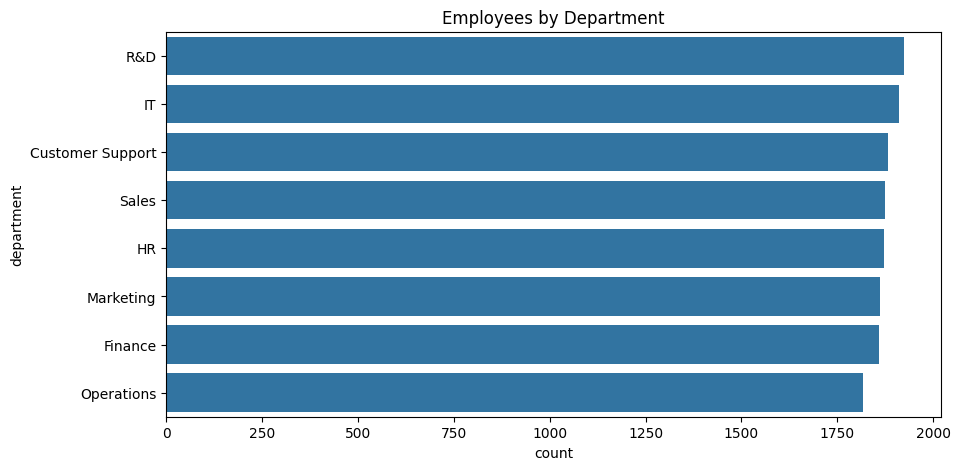

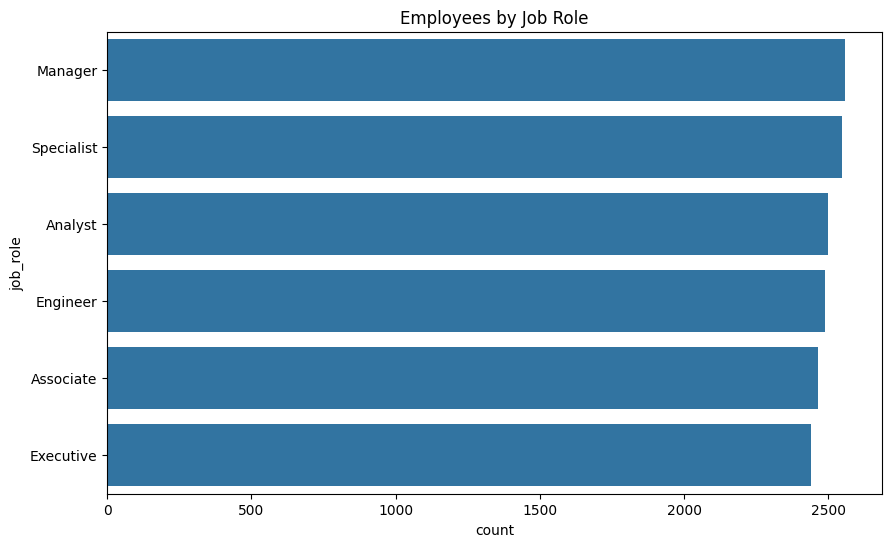

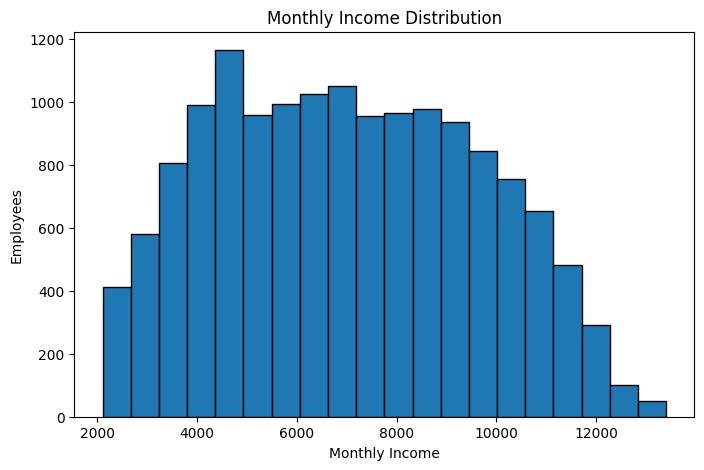

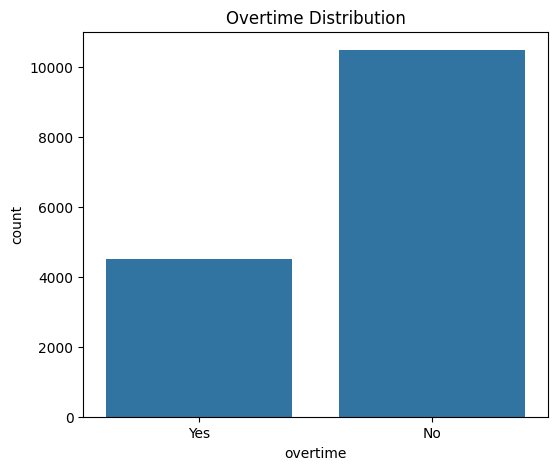

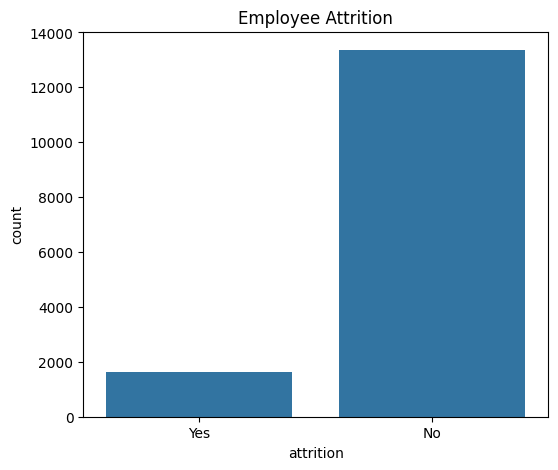

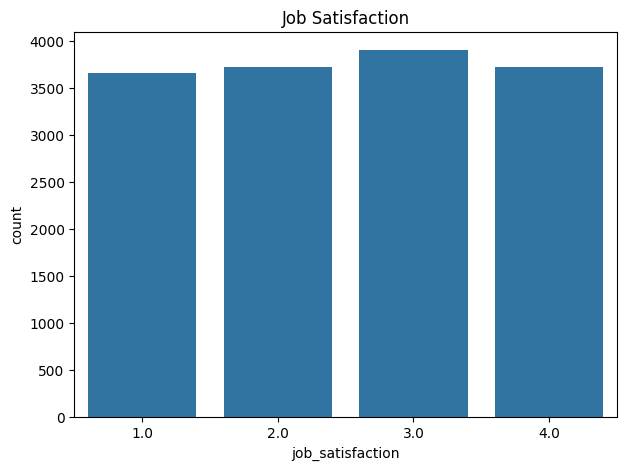

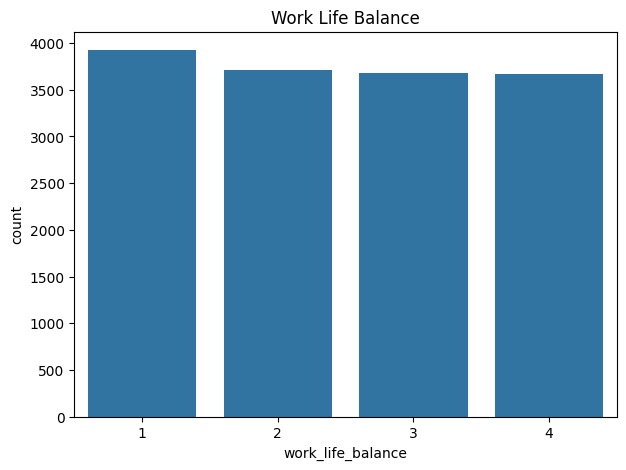

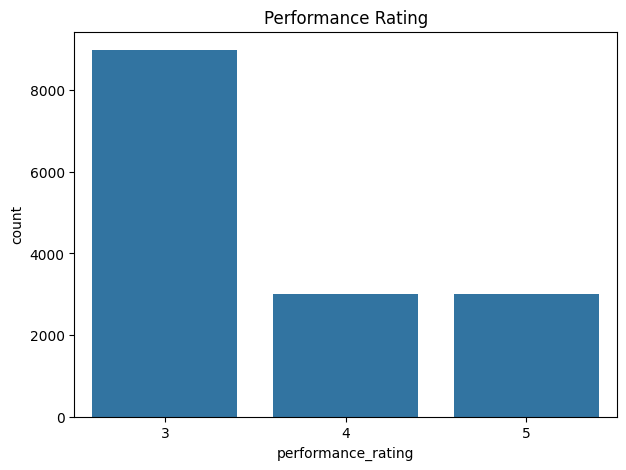

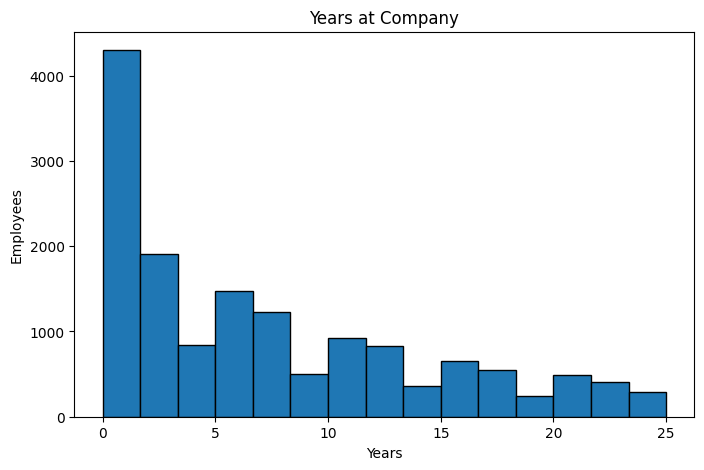

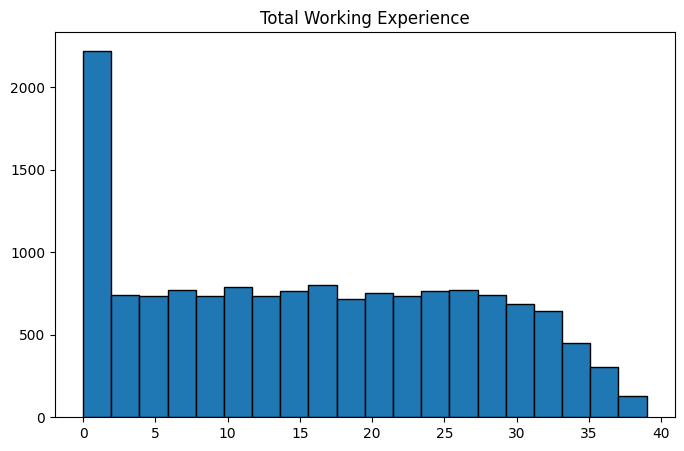

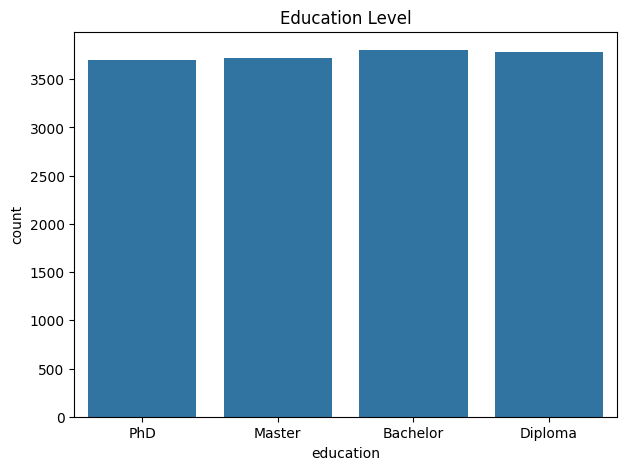

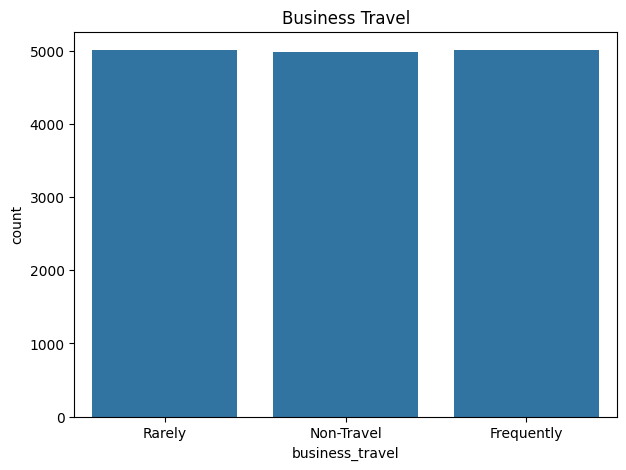

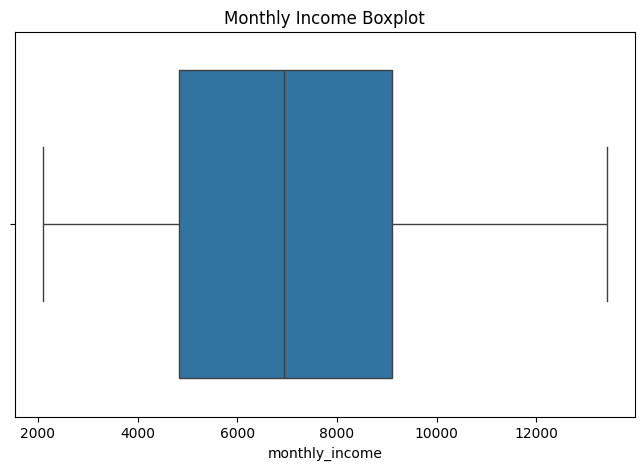

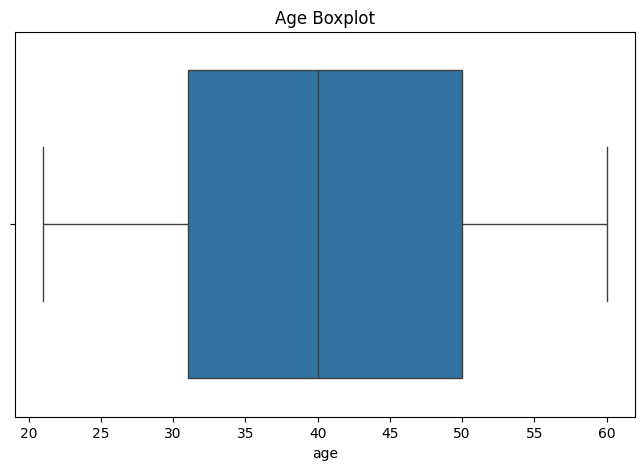

,proportion
gender,
Male,50.13
Female,49.87


In [36]:
df_eda = df_fe.copy()
plt.figure(figsize=(8,5))

plt.hist(df_eda["age"], bins=15, edgecolor="black")

plt.title("Employee Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Employees")

plt.show()
plt.figure(figsize=(6,5))

sns.countplot(x="gender", data=df_eda)

plt.title("Gender Distribution")

plt.show()
plt.figure(figsize=(10,5))

sns.countplot(
    y="department",
    data=df_eda,
    order=df_eda["department"].value_counts().index
)

plt.title("Employees by Department")

plt.show()
plt.figure(figsize=(10,6))

sns.countplot(
    y="job_role",
    data=df_eda,
    order=df_eda["job_role"].value_counts().index
)

plt.title("Employees by Job Role")

plt.show()
plt.figure(figsize=(8,5))

plt.hist(df_eda["monthly_income"], bins=20, edgecolor="black")

plt.title("Monthly Income Distribution")

plt.xlabel("Monthly Income")

plt.ylabel("Employees")

plt.show()
plt.figure(figsize=(6,5))

sns.countplot(x="overtime", data=df_eda)

plt.title("Overtime Distribution")

plt.show()
plt.figure(figsize=(6,5))

sns.countplot(x="attrition", data=df_eda)

plt.title("Employee Attrition")

plt.show()
plt.figure(figsize=(7,5))

sns.countplot(x="job_satisfaction", data=df_eda)

plt.title("Job Satisfaction")

plt.show()
plt.figure(figsize=(7,5))

sns.countplot(x="work_life_balance", data=df_eda)

plt.title("Work Life Balance")

plt.show()
plt.figure(figsize=(7,5))

sns.countplot(x="performance_rating", data=df_eda)

plt.title("Performance Rating")

plt.show()
plt.figure(figsize=(8,5))

plt.hist(
    df_eda["years_at_company"],
    bins=15,
    edgecolor="black"
)

plt.title("Years at Company")

plt.xlabel("Years")

plt.ylabel("Employees")

plt.show()
plt.figure(figsize=(8,5))

plt.hist(
    df_eda["total_working_years"],
    bins=20,
    edgecolor="black"
)

plt.title("Total Working Experience")

plt.show()
plt.figure(figsize=(7,5))

sns.countplot(x="education", data=df_eda)

plt.title("Education Level")

plt.show()
plt.figure(figsize=(7,5))

sns.countplot(x="business_travel", data=df_eda)

plt.title("Business Travel")

plt.show()
plt.figure(figsize=(8,5))

sns.boxplot(x=df_eda["monthly_income"])

plt.title("Monthly Income Boxplot")

plt.show()
plt.figure(figsize=(8,5))

sns.boxplot(x=df_eda["age"])

plt.title("Age Boxplot")

plt.show()
df_eda.describe()
df_eda["department"].value_counts()
df_eda["gender"].value_counts()
df_eda["attrition"].value_counts()
df_eda["education"].value_counts()
round(df_eda["attrition"].value_counts(normalize=True)*100,2)
round(df_eda["gender"].value_counts(normalize=True)*100,2)

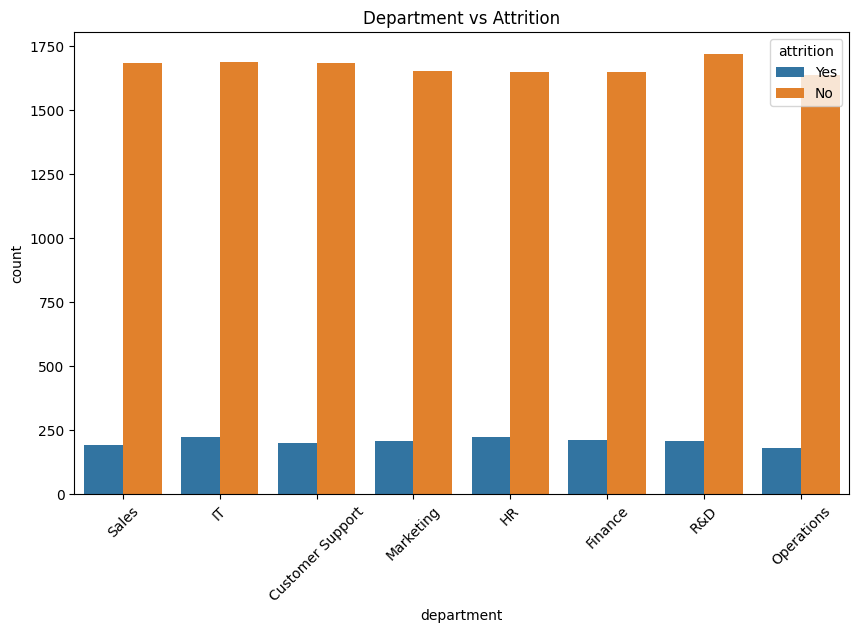

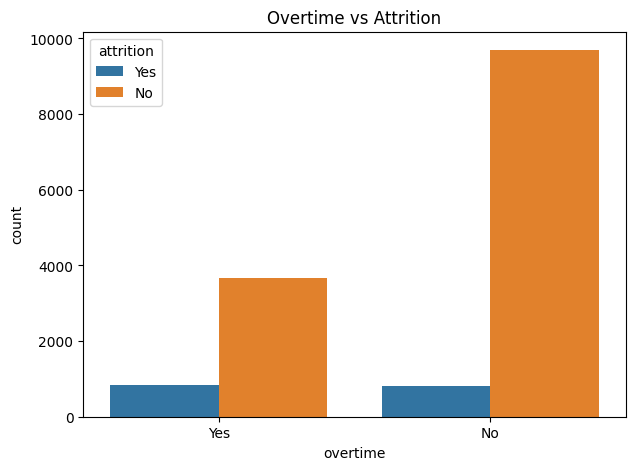

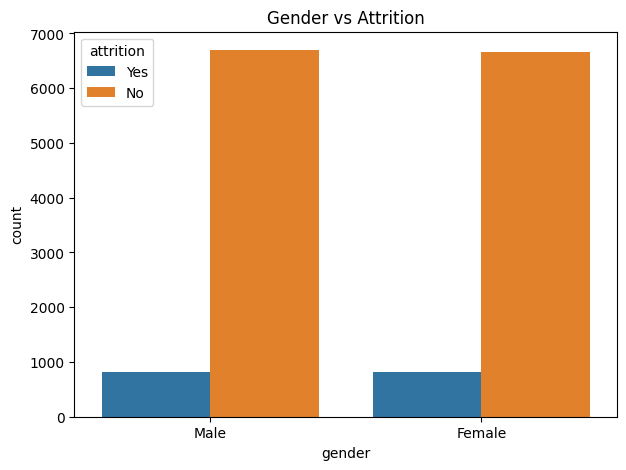

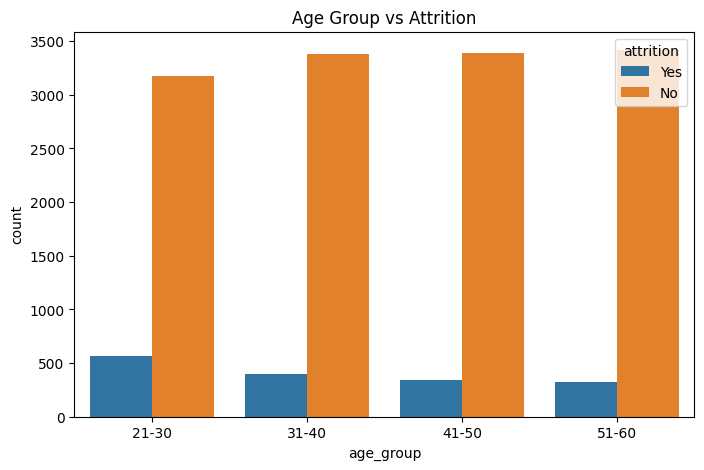

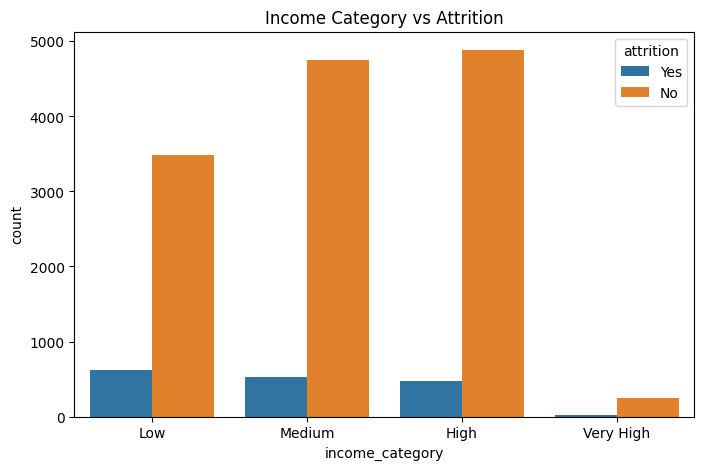

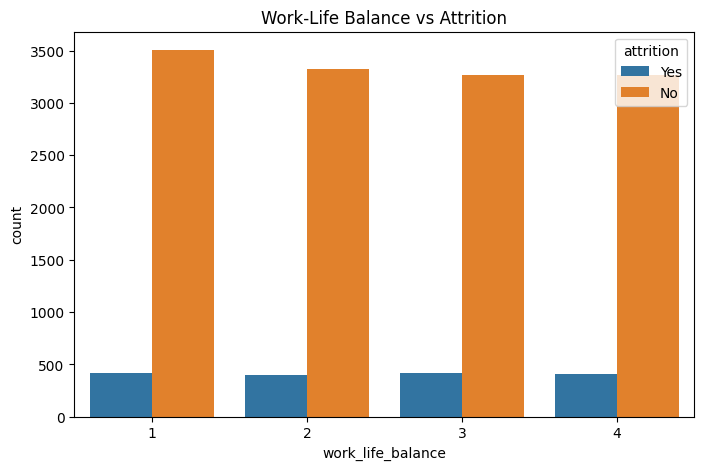

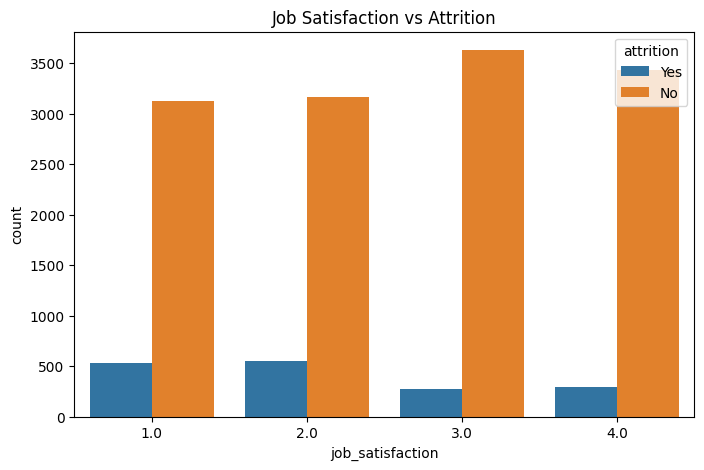

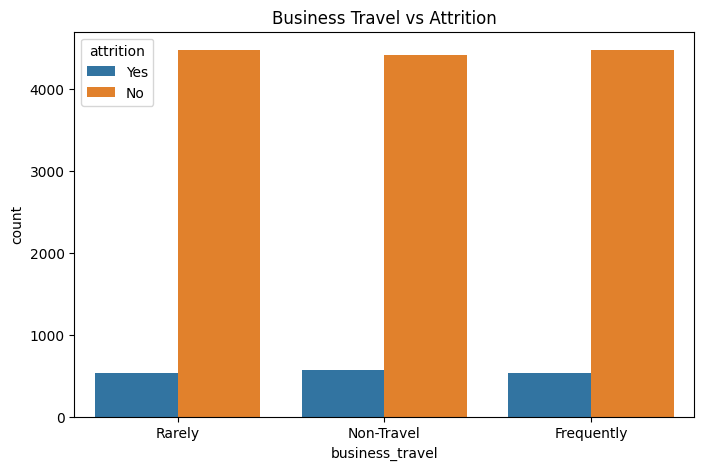

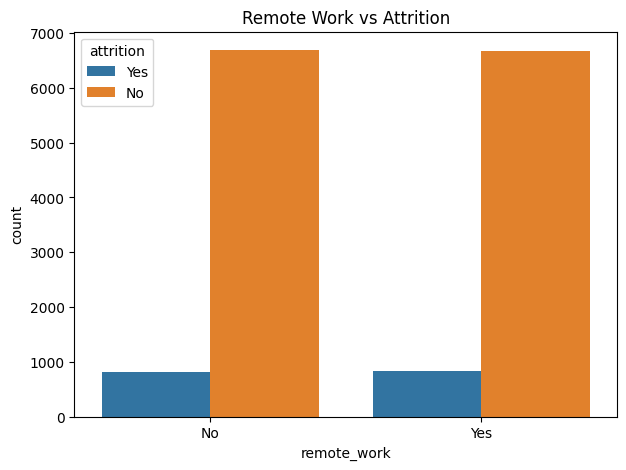

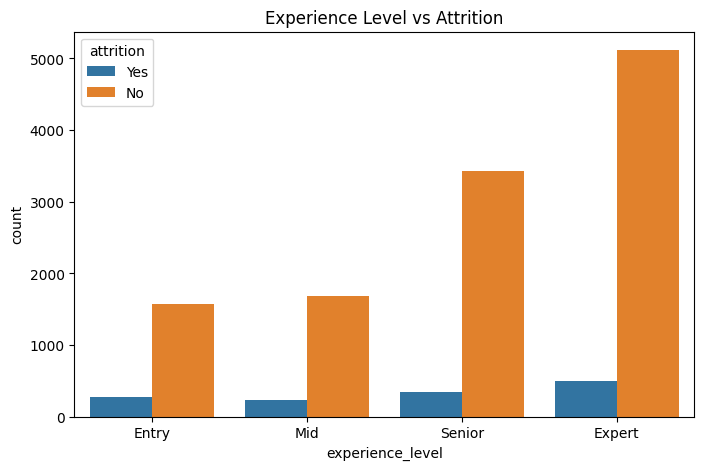

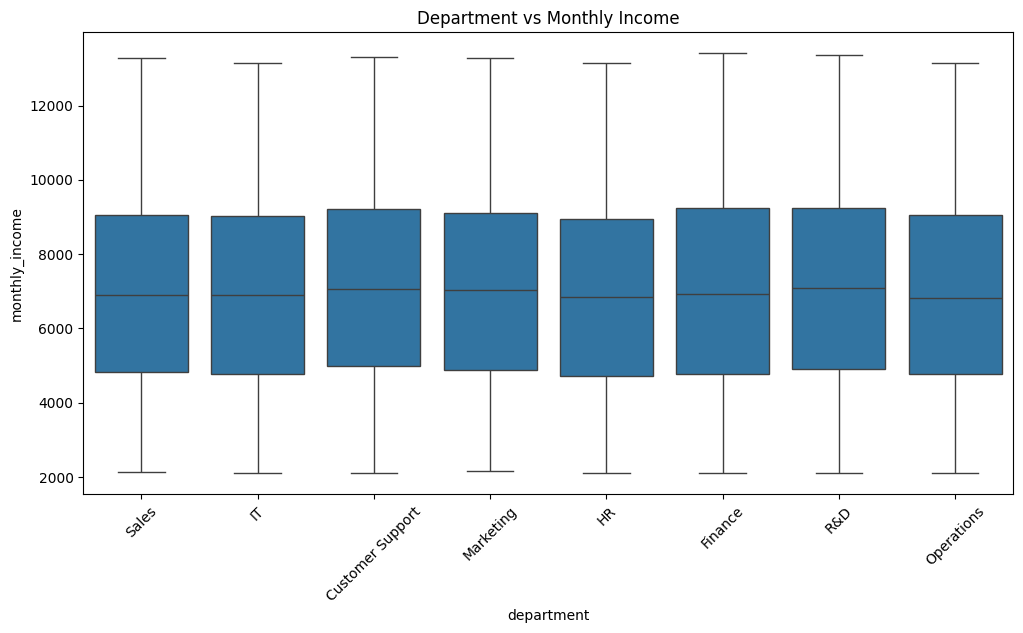

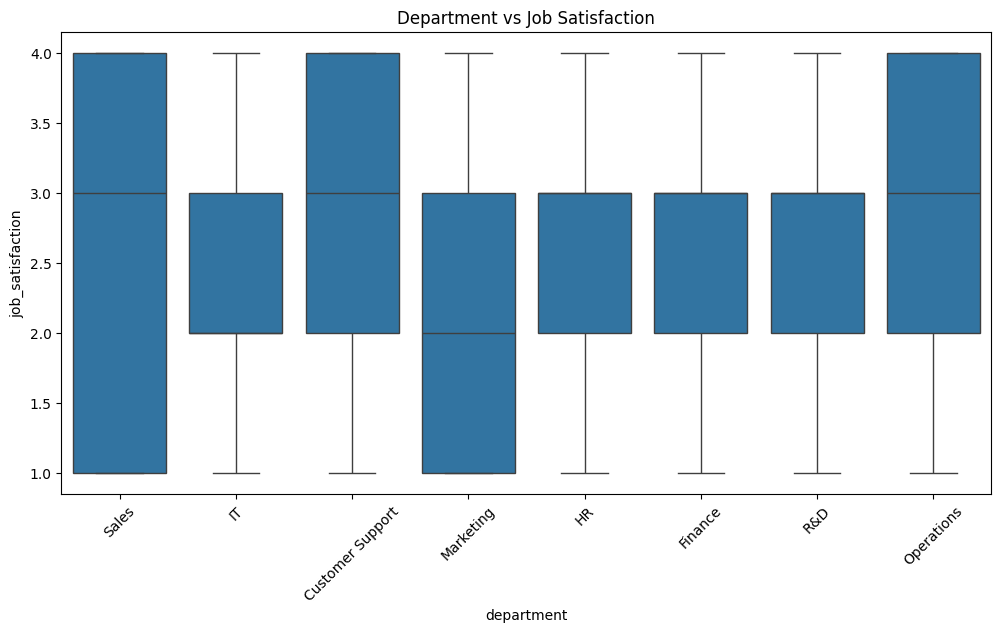

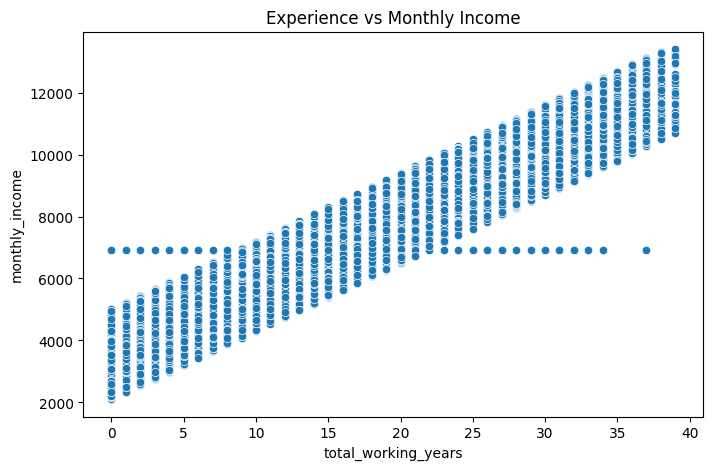

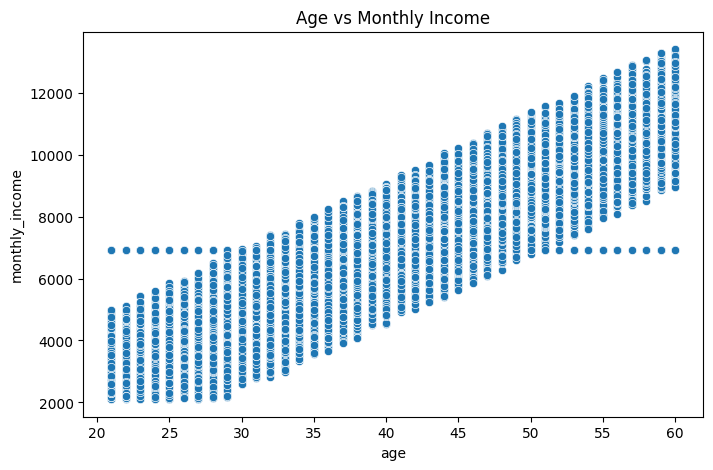

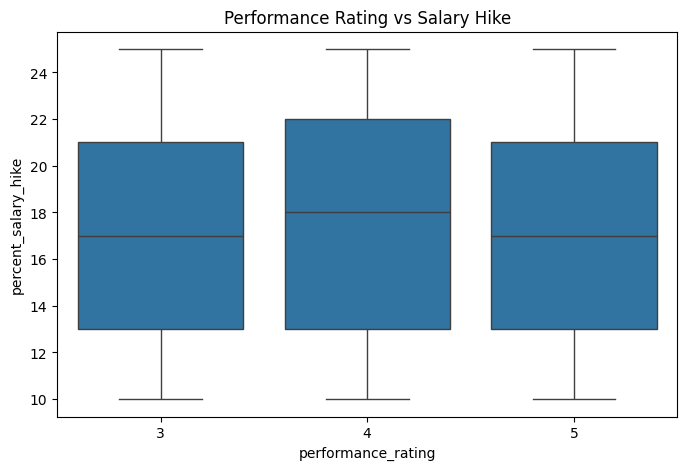

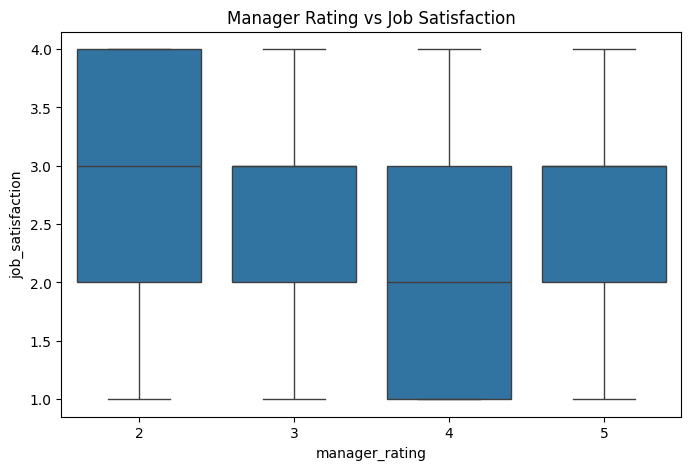

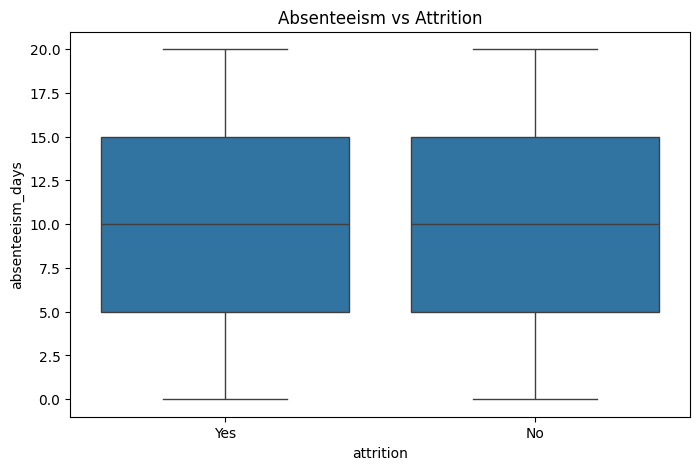

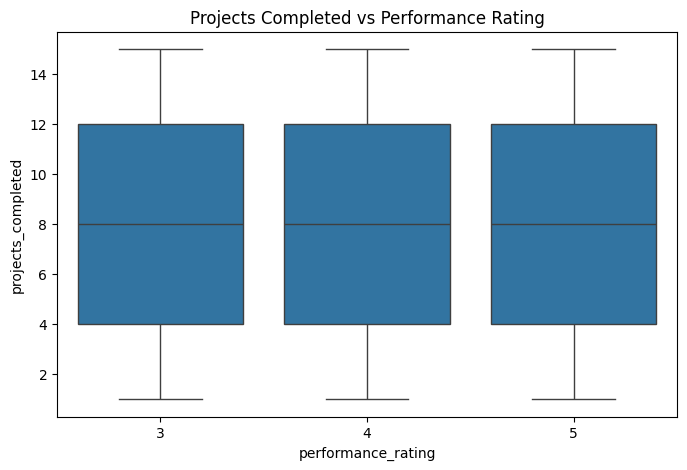

,monthly_income
job_role,
Engineer,7090.75
Specialist,7056.95
Associate,7031.07
Executive,7025.43
Analyst,6997.17
Manager,6971.86


In [37]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df_eda,
    x="department",
    hue="attrition"
)

plt.title("Department vs Attrition")
plt.xticks(rotation=45)

plt.show()
plt.figure(figsize=(7,5))

sns.countplot(
    data=df_eda,
    x="overtime",
    hue="attrition"
)

plt.title("Overtime vs Attrition")

plt.show()
plt.figure(figsize=(7,5))

sns.countplot(
    data=df_eda,
    x="gender",
    hue="attrition"
)

plt.title("Gender vs Attrition")

plt.show()
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_eda,
    x="age_group",
    hue="attrition"
)

plt.title("Age Group vs Attrition")

plt.show()
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_eda,
    x="income_category",
    hue="attrition"
)

plt.title("Income Category vs Attrition")

plt.show()
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_eda,
    x="work_life_balance",
    hue="attrition"
)

plt.title("Work-Life Balance vs Attrition")

plt.show()
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_eda,
    x="job_satisfaction",
    hue="attrition"
)

plt.title("Job Satisfaction vs Attrition")

plt.show()
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_eda,
    x="business_travel",
    hue="attrition"
)

plt.title("Business Travel vs Attrition")

plt.show()
plt.figure(figsize=(7,5))

sns.countplot(
    data=df_eda,
    x="remote_work",
    hue="attrition"
)

plt.title("Remote Work vs Attrition")

plt.show()
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_eda,
    x="experience_level",
    hue="attrition"
)

plt.title("Experience Level vs Attrition")

plt.show()
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_eda,
    x="department",
    y="monthly_income"
)

plt.xticks(rotation=45)

plt.title("Department vs Monthly Income")

plt.show()
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_eda,
    x="department",
    y="job_satisfaction"
)

plt.xticks(rotation=45)

plt.title("Department vs Job Satisfaction")

plt.show()
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_eda,
    x="total_working_years",
    y="monthly_income"
)

plt.title("Experience vs Monthly Income")

plt.show()
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_eda,
    x="age",
    y="monthly_income"
)

plt.title("Age vs Monthly Income")

plt.show()
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_eda,
    x="performance_rating",
    y="percent_salary_hike"
)

plt.title("Performance Rating vs Salary Hike")

plt.show()
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_eda,
    x="manager_rating",
    y="job_satisfaction"
)

plt.title("Manager Rating vs Job Satisfaction")

plt.show()
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_eda,
    x="attrition",
    y="absenteeism_days"
)

plt.title("Absenteeism vs Attrition")

plt.show()
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_eda,
    x="performance_rating",
    y="projects_completed"
)

plt.title("Projects Completed vs Performance Rating")

plt.show()

department_attrition = pd.crosstab(
    df_eda["department"],
    df_eda["attrition"]
)

department_attrition
df_eda.groupby("department")["monthly_income"].mean().sort_values(ascending=False)
df_eda.groupby("department")["job_satisfaction"].mean().sort_values(ascending=False)
df_eda.groupby("job_role")["monthly_income"].mean().sort_values(ascending=False)

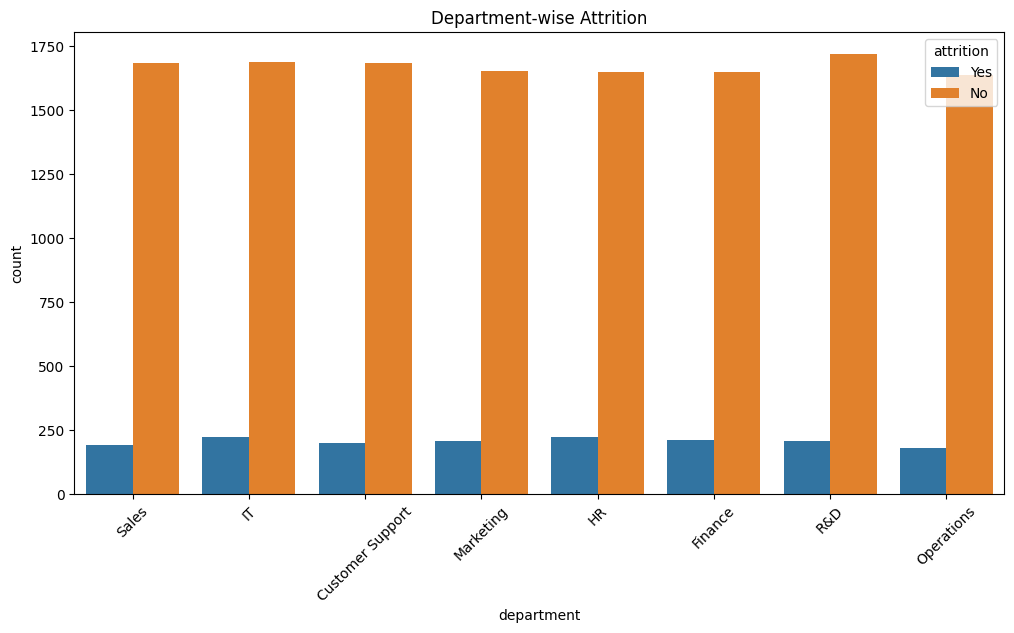

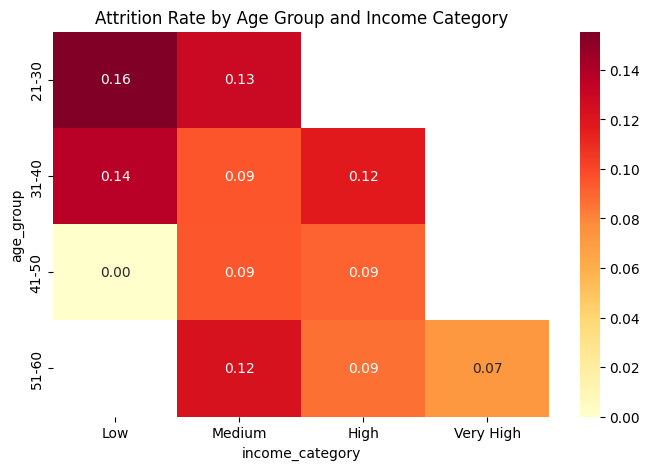

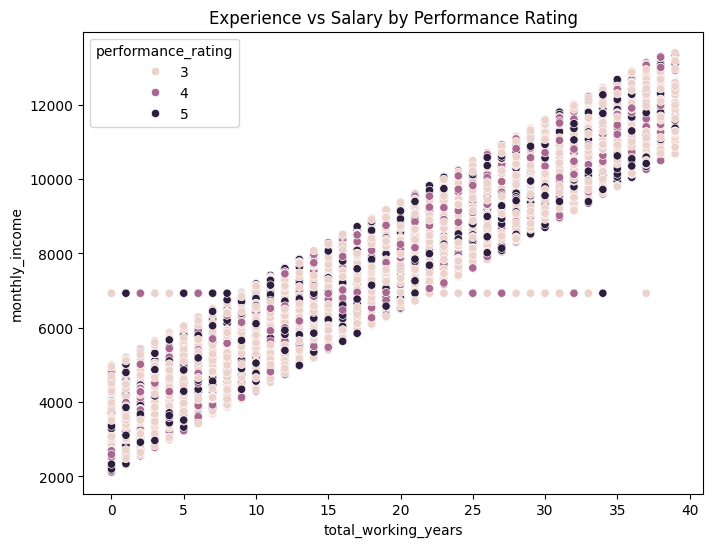

gender,Female,Male
department,,
Customer Support,0.10,0.11
Finance,0.11,0.11
HR,0.12,0.12
IT,0.12,0.11
Marketing,0.11,0.11
Operations,0.10,0.10
R&D,0.11,0.10
Sales,0.10,0.10


In [38]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df_eda,
    x="department",
    hue="attrition"
)

plt.title("Department-wise Attrition")
plt.xticks(rotation=45)

plt.show()
pd.crosstab(
    [df_eda["department"], df_eda["overtime"]],
    df_eda["attrition"]
)
pivot = pd.pivot_table(
    df_eda,
    values="attrition_flag",
    index="age_group",
    columns="income_category",
    aggfunc="mean"
)

plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, cmap="YlOrRd", fmt=".2f")

plt.title("Attrition Rate by Age Group and Income Category")
plt.show()
dept_summary = df_eda.groupby("department").agg({
    "monthly_income":"mean",
    "job_satisfaction":"mean"
})

dept_summary
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_eda,
    x="total_working_years",
    y="monthly_income",
    hue="performance_rating"
)

plt.title("Experience vs Salary by Performance Rating")

plt.show()

department_dashboard = df_eda.groupby("department").agg({
    "monthly_income":"mean",
    "job_satisfaction":"mean",
    "performance_rating":"mean",
    "attrition_flag":"mean"
})

department_dashboard
pivot = pd.pivot_table(
    df_eda,
    values="attrition_flag",
    index="department",
    columns="gender",
    aggfunc="mean"
)

pivot


In [39]:
total_employees = len(df_eda)

attrition_rate = (df_eda["attrition"] == "Yes").mean() * 100

average_salary = df_eda["monthly_income"].mean()

average_age = df_eda["age"].mean()

average_experience = df_eda["total_working_years"].mean()

print(f"Total Employees: {total_employees}")
print(f"Attrition Rate: {attrition_rate:.2f}%")
print(f"Average Salary: {average_salary:.2f}")
print(f"Average Age: {average_age:.2f}")
print(f"Average Experience: {average_experience:.2f}")
department_kpi = df_eda.groupby("department").agg({
    "monthly_income":"mean",
    "job_satisfaction":"mean",
    "performance_rating":"mean",
    "attrition_flag":"mean"
}).round(2)

department_kpi
print("Highest Average Salary Department")
print(df_eda.groupby("department")["monthly_income"].mean().idxmax())

print("\nLowest Average Salary Department")
print(df_eda.groupby("department")["monthly_income"].mean().idxmin())

print("\nHighest Attrition Department")
print(df_eda.groupby("department")["attrition_flag"].mean().idxmax())

print("\nHighest Job Satisfaction Department")
print(df_eda.groupby("department")["job_satisfaction"].mean().idxmax())
overtime_summary = df_eda.groupby("overtime").agg({
    "attrition_flag":"mean",
    "monthly_income":"mean"
}).round(2)

overtime_summary
print("Department Distribution")
print(df_eda["department"].value_counts())

print("\nGender Distribution")
print(df_eda["gender"].value_counts())

print("\nEducation Distribution")
print(df_eda["education"].value_counts())
top_salary_roles = df_eda.groupby("job_role")["monthly_income"] \
.mean() \
.sort_values(ascending=False) \
.head(5)

top_salary_roles
kpi_summary = pd.DataFrame({
    "KPI":[
        "Total Employees",
        "Attrition Rate",
        "Average Salary",
        "Average Age",
        "Average Experience"
    ],
    "Value":[
        total_employees,
        round(attrition_rate,2),
        round(average_salary,2),
        round(average_age,2),
        round(average_experience,2)
    ]
})

kpi_summary


Total Employees: 15000
Attrition Rate: 10.93%
Average Salary: 7028.70
Average Age: 40.52
Average Experience: 15.85
Highest Average Salary Department
Customer Support

Lowest Average Salary Department
HR

Highest Attrition Department
HR

Highest Job Satisfaction Department
Customer Support
Department Distribution
department
R&D                 1924
IT                  1910
Customer Support    1882
Sales               1875
HR                  1872
Marketing           1862
Finance             1859
Operations          1816
Name: count, dtype: int64

Gender Distribution
gender
Male      7520
Female    7480
Name: count, dtype: int64

Education Distribution
education
Bachelor    3802
Diploma     3777
Master      3723
PhD         3698
Name: count, dtype: int64


,KPI,Value
0,Total Employees,15000.00
1,Attrition Rate,10.93
2,Average Salary,7028.70
3,Average Age,40.52
4,Average Experience,15.85


Total Employees: 15000
Attrition Rate: 10.93 %
Average Salary: 7028.7
Average Age: 40.52


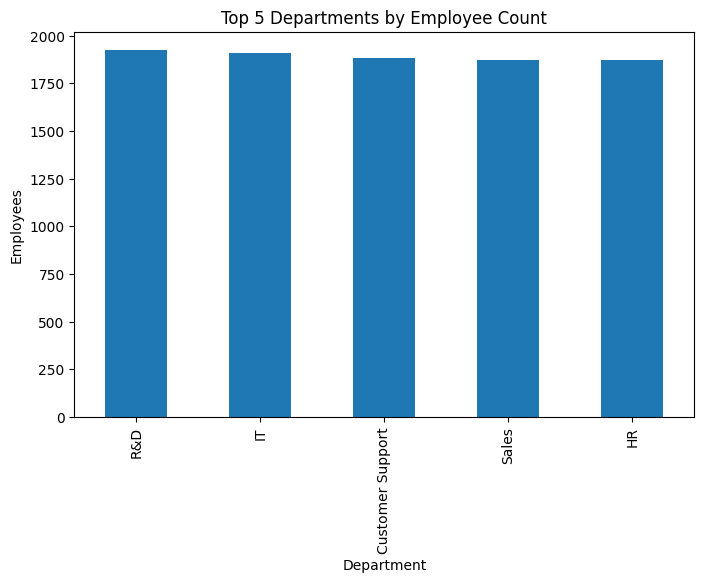

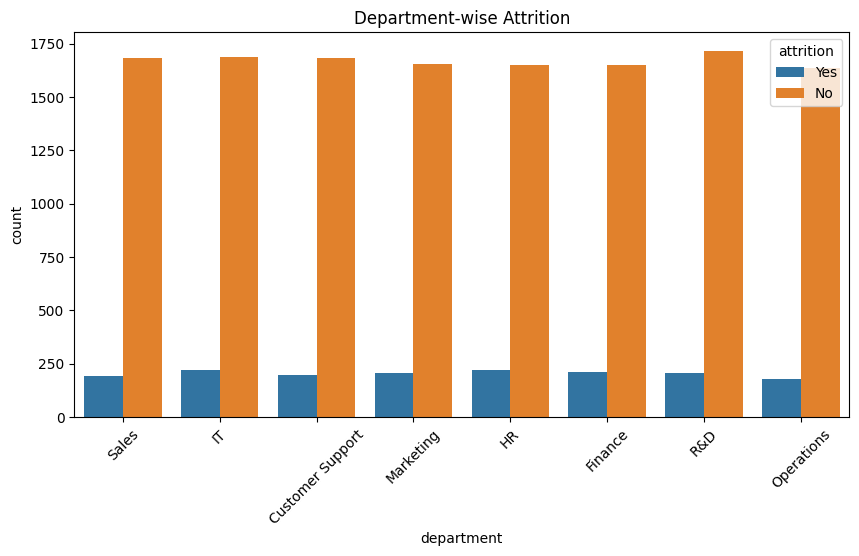

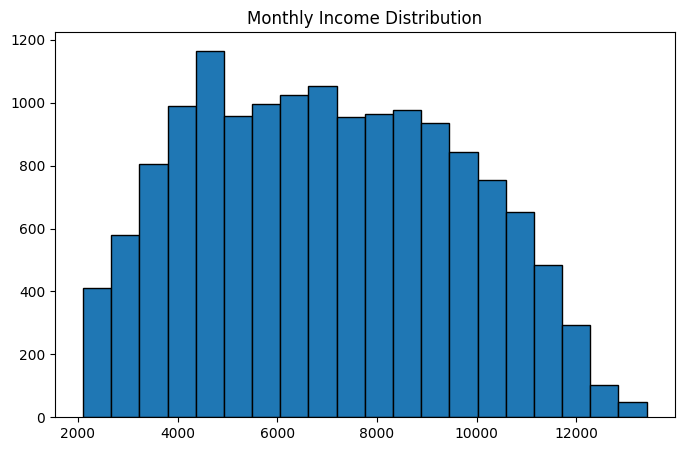

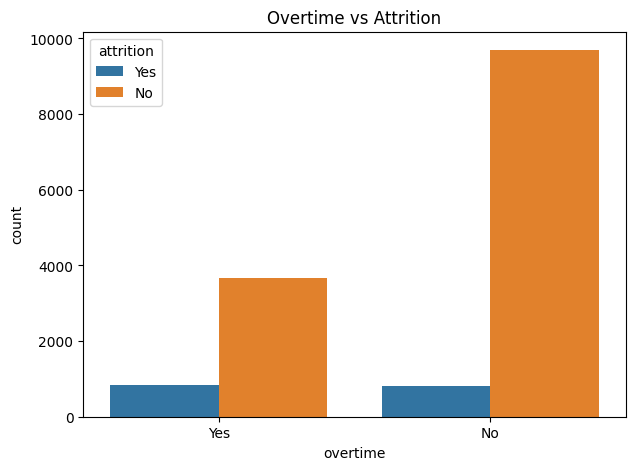

,Metric,Value
0,Total Employees,15000.00
1,Attrition Rate,10.93
2,Average Salary,7028.70
3,Average Age,40.52
4,Average Experience,15.85


In [40]:
total_employees = len(df_eda)
attrition_rate = round((df_eda["attrition"]=="Yes").mean()*100,2)
average_salary = round(df_eda["monthly_income"].mean(),2)
average_age = round(df_eda["age"].mean(),2)

print("Total Employees:", total_employees)
print("Attrition Rate:", attrition_rate,"%")
print("Average Salary:", average_salary)
print("Average Age:", average_age)
plt.figure(figsize=(8,5))

df_eda["department"].value_counts().head(5).plot(kind="bar")

plt.title("Top 5 Departments by Employee Count")
plt.xlabel("Department")
plt.ylabel("Employees")

plt.show()
plt.figure(figsize=(10,5))

sns.countplot(
    data=df_eda,
    x="department",
    hue="attrition"
)

plt.xticks(rotation=45)

plt.title("Department-wise Attrition")

plt.show()
plt.figure(figsize=(8,5))

plt.hist(df_eda["monthly_income"],
         bins=20,
         edgecolor="black")

plt.title("Monthly Income Distribution")

plt.show()
plt.figure(figsize=(7,5))

sns.countplot(
    data=df_eda,
    x="overtime",
    hue="attrition"
)

plt.title("Overtime vs Attrition")

plt.show()

dashboard_summary = pd.DataFrame({
    "Metric":[
        "Total Employees",
        "Attrition Rate",
        "Average Salary",
        "Average Age",
        "Average Experience"
    ],
    "Value":[
        total_employees,
        attrition_rate,
        average_salary,
        average_age,
        round(df_eda["total_working_years"].mean(),2)
    ]
})

dashboard_summary


In [41]:
project_summary = pd.DataFrame({
    "Phase":[
        "Data Cleaning",
        "Feature Engineering",
        "EDA",
        "KPI Analysis",
        "Dashboard",
        "Business Insights"
    ],
    "Status":[
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed"
    ]
})

project_summary

,Phase,Status
0,Data Cleaning,Completed
1,Feature Engineering,Completed
2,EDA,Completed
3,KPI Analysis,Completed
4,Dashboard,Completed
5,Business Insights,Completed
